In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("../data/revenue_per_customer.csv")


In [48]:
#sortowanie całej tabeli malejąco

df = df.sort_values(by='revenue',ascending=False).reset_index(drop=True)

In [49]:
#suma kumulatywna dla przychodu

df["cumulative_revenue"] = df['revenue'].cumsum()
total_revenue = df['revenue'].sum()


#procent kumulatywny z przychodu
df["cumulative_percentage"] = (df['cumulative_revenue']/total_revenue * 100).round(2)


#udział klientów (ilu klientów już uwzględniliśmy)
df['customer_share'] = (df.index + 1) / len(df) * 100
df['customer_share'] = df['customer_share'].round(3)

In [50]:

#sanity check
print(df["customer_share"].max())
print(df["cumulative_percentage"].max())

100.0
100.0


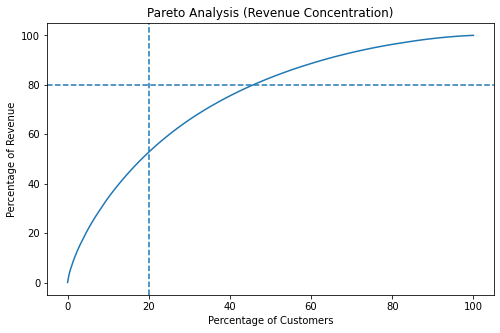

In [51]:
plt.figure(figsize=(8,5))

sns.lineplot(x = df["customer_share"], y = df["cumulative_percentage"])

plt.axhline(80, linestyle='--')
plt.axvline(20, linestyle='--')

plt.title("Pareto Analysis (Revenue Concentration)")
plt.xlabel("Percentage of Customers")
plt.ylabel("Percentage of Revenue")

plt.show()

In [52]:
top_20 = df[df["customer_share"] <= 20]["revenue"].sum()
total = df["revenue"].sum()

share_top_20 = round(top_20 / total * 100, 2)

print(f"Top 20% customers generate {share_top_20}% of revenue")

Top 20% customers generate 52.76% of revenue


## Key Insights:

Revenue is moderately concentrated among top customers.

The top 20% of customers generate 52.76% of total revenue,
indicating that while high-value customers are important,
a significant portion of revenue is still generated by the broader customer base.

This suggests a more balanced revenue distribution compared to a typical 80/20 scenario.

## Business recommendation:

The results suggest that revenue is not driven only by top customers.

While high-value users are still important, a large part of revenue comes
from the wider customer base. This means that focusing only on top spenders
would miss a significant growth opportunity.

Instead, the business should also focus on increasing purchase frequency
among regular customers and encouraging them to come back more often.
Even small improvements in retention across this group could have a meaningful
impact on overall revenue.
